# ASP25/124 H-Bond Frequency Clustermap

**What this notebook does:**
- Reads per-simulation interaction CSV files (binary H-bond presence per frame)
- Filters columns to those involving **ASP25, ASP124** and nearby residues
  (residue IDs 23–28 and 123–128)
- Computes the **% frequency** of each H-bond in each simulation
- Keeps only bonds present in ≥ 25 % of frames in at least one simulation
- Produces a **seaborn clustermap** — rows are H-bonds (clustered), columns are
  simulations (kept in order)

**Sections:**
1. Imports
2. Configuration (paths, residue filter)
3. Helper functions: `find_asp_int()`, `analyze_asp_hbonds()`, `get_res_num()`
4. Compute frequency table
5. Filter and rename columns
6. Plot clustermap


In [102]:
# 1. Imports
import os
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [105]:
# 2. Configuration
ROOTDIR    = '/content/drive/MyDrive/M1_STAGE/Data/interactions/'
# If running on Colab, replace with:
# ROOTDIR = '/content/drive/MyDrive/M1_STAGE/Data/interactions/'
OUTPUT_DIR = '//content/drive/MyDrive/M1_STAGE/Manips/Figures/'

INTERACTION_FILES = [
    'res_V1.csv', 'res_V11.csv', 'res_V12.csv',
    'res_V7.csv', 'res_V8.csv', 'res_V21.csv'
]
SIMULATION_NAMES = ['V1', 'V11', 'V12', 'V7', 'V8', 'V21']

# Residue IDs to include in the H-bond search
RESID_LIST = ['23','24','25','26','27','28','123','124','125','126','128']

# Minimum frequency threshold (%) to retain a bond
MIN_FREQ = 25

os.chdir(ROOTDIR)

In [106]:
# 3. Helper functions

def find_asp_int(interactions_file: str) -> None:
    """Print all H-bond columns involving ASP_25 that are ever non-zero."""
    df = pd.read_csv(interactions_file)
    for col in [c for c in df.columns if 'ASP_25' in c and 'hb' in c]:
        if df[col].sum() > 0:
            print(col)


def analyze_asp_hbonds(interactions_file: str) -> dict:
    """
    Compute the % frequency of H-bonds involving residues in RESID_LIST.

    Returns
    -------
    dict mapping column name → frequency (%)
    """
    df = pd.read_csv(interactions_file)
    n_frames = len(df)
    hb_cols = [c for c in df.columns if 'hb' in c and any(r in c for r in RESID_LIST)]
    return {col: (df[col] > 0).sum() / n_frames * 100 for col in hb_cols}


def get_res_num(interaction_string: str) -> int:
    """Extract the first residue number from a bond column name."""
    match = re.search(r'\d+', interaction_string)
    return int(match.group()) if match else 0

In [107]:
# 4. Compute frequency table across all simulations
all_results = []
for sim_file in INTERACTION_FILES:
    data = analyze_asp_hbonds(sim_file)
    all_results.append(data)

freq_table = pd.DataFrame(all_results, index=SIMULATION_NAMES)
print(f'Frequency table shape: {freq_table.shape} (simulations × bonds)')
freq_table.head()

Frequency table shape: (6, 269) (simulations × bonds)


,hbbb_ASN_187_N_ASP_128_O,hbsb_ASP_124_OD1_GLY_126_N,hbbb_ALA_28_N_THR_26_O,hbbb_ARG_186_N_ASP_128_O,hbsb_ARG_8_NH2_GLY_126_N,hbsb_ASPH_124_OD1_THR_125_N,hbss_ASP_128_OD2_TRP_6_NE1,hbss_ARG_8_NH2_THR_125_OG1,hbss_ARG_107_NH1_THR_125_OG1,hbsb_ASP_25_OD1_GLY_126_N,...,hbss_ARG_8_NH2_ASP_128_OD1,hbss_ASN_187_ND2_ASP_128_OD1,hbss_ARG_186_NH1_ASP_25_OD2,hbsb_ASP_25_OD1_GLY_27_N,hbsb_ARG_186_NH1_ASP_128_N,hbsb_ARG_107_NH2_GLY_27_O,hbss_ARG_107_NE_ASP_124_OD2,hbsb_ARG_186_NH1_THR_26_N,hbsb_LEU_5_O_THR_125_OG1,hbsb_ARG_87_NH1_GLY_126_O
V1,24.875125,39.460539,14.385614,0.499500,0.0,0.0,0.000000,0.999001,0.0000,0.000000,...,4.095904,1.498501,61.238761,71.028971,0.0000,0.000000,13.986014,0.199800,0.199800,0.0999
V11,80.019980,51.448551,4.995005,2.197802,0.0,0.0,6.293706,1.098901,0.0999,0.000000,...,9.890110,1.598402,22.177822,49.150849,0.0999,0.499500,8.091908,1.198801,1.098901,0.0999
V12,32.967033,47.552448,0.299700,0.099900,0.0,0.0,0.000000,0.099900,0.0000,1.798202,...,8.891109,0.999001,0.000000,34.265734,0.0000,11.688312,0.799201,0.000000,0.000000,0.0000
V7,63.736264,63.336663,0.799201,0.000000,0.0,0.0,0.000000,0.000000,0.0000,39.460539,...,21.378621,0.499500,0.000000,53.746254,0.0000,6.593407,0.000000,0.000000,0.000000,0.0000
V8,76.646707,73.053892,0.798403,0.199601,0.0,0.0,0.000000,0.000000,0.0000,41.317365,...,7.185629,2.395210,0.000000,51.696607,0.0000,5.389222,0.000000,0.000000,0.000000,0.0000


In [108]:
# 5. Filter: keep bonds present in >= MIN_FREQ % in at least one simulation
filtered_cols = freq_table.columns[(freq_table > MIN_FREQ).any()]
freq_filtered = freq_table[filtered_cols].copy()
print(f'Bonds retained after {MIN_FREQ}% filter: {len(filtered_cols)}')

# Build human-readable column labels
descriptive_labels = []
for bond in freq_filtered.columns:
    parts = bond.split('_')
    try:
        res1 = f"{parts[1]:<3}{parts[2]:>3}_{parts[3]:<3}"
        res2 = f"{parts[4]:<3}{parts[5]:>3}_{parts[6]:<3}"
        descriptive_labels.append(f"{res2} - {res1}")
    except IndexError:
        descriptive_labels.append(bond)  # fallback to raw name

freq_filtered = freq_filtered.rename(
    columns=dict(zip(freq_filtered.columns, descriptive_labels))
)

# Sort columns by first residue number
sorted_cols = sorted(freq_filtered.columns, key=get_res_num)
df_sorted   = freq_filtered[sorted_cols]
df_sorted.head()

Bonds retained after 25% filter: 60


,PRO 9_O - LEU 24_N,LEU 23_O - ASP 25_N,LEU 23_N - ASN 83_O,ASP 25_OD2 - ARG186_NH2,ASP 25_OD2 - ALA 28_N,ASP 25_OD2 - ASP124_OD2,ASP 25_OD1 - ARG186_NH1,ASP 25_OD1 - ASP124_OD2,ASP 25_OD1 - ARG186_NH2,ASP 25_OD1 - ALA 28_N,...,ASP128_OD2 - ARG 8_NH2,ASP128_OD2 - ARG186_NH2,ASP128_OD1 - ARG 8_NE,ASP128_OD1 - ARG186_NE,ASP128_OD1 - ARG186_NH2,ASP128_OD2 - ARG 8_NE,ASP128_OD2 - ARG186_NE,ASP128_OD1 - ARG 8_NH2,PHE184_O - ASP124_N,ARG186_N - ALA127_O
V1,98.301698,19.380619,96.303696,66.733267,12.687313,0.000000,69.83017,0.000000,26.173826,7.892108,...,4.895105,6.293706,0.000000,2.797203,5.394605,0.000000,4.095904,4.095904,90.609391,95.304695
V11,93.006993,27.072927,98.901099,12.987013,27.172827,0.000000,20.47952,0.000000,11.088911,24.875125,...,10.789211,25.574426,0.000000,12.087912,24.275724,0.000000,14.585415,9.890110,32.167832,97.202797
V12,95.204795,3.696304,91.608392,0.000000,48.451548,0.000000,0.00000,0.000000,0.000000,36.863137,...,9.790210,29.770230,11.888112,10.789211,31.668332,11.488511,11.088911,8.891109,99.000999,97.902098
V7,97.402597,4.395604,99.200799,0.000000,26.173826,78.021978,0.00000,73.826174,0.000000,24.775225,...,19.680320,54.445554,24.575425,22.677323,47.452547,25.374625,28.771229,21.378621,99.500500,99.300699
V8,91.017964,2.594810,99.600798,0.000000,28.942116,72.854291,0.00000,77.045908,0.000000,28.942116,...,7.584830,67.065868,8.383234,26.147705,59.281437,9.980040,50.499002,7.185629,99.600798,99.401198


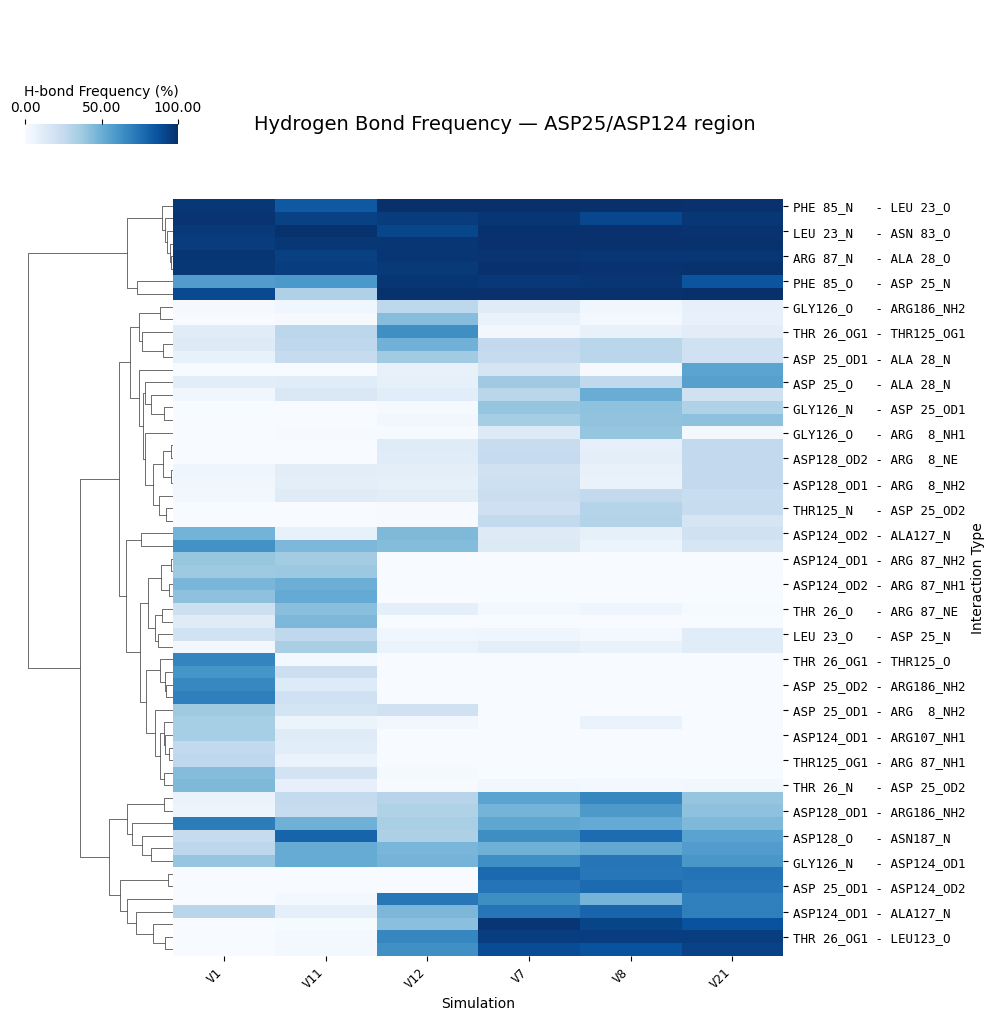

In [160]:
# 6. Plot clustermap (rows = H-bonds clustered; columns = simulations in order)
g = sns.clustermap(
    df_sorted.T,
    cmap='Blues',
    col_cluster=False,   # preserve simulation order on x-axis
    row_cluster=True,    # group similar H-bonds together on y-axis
    figsize=(10, max(10, len(df_sorted.columns) * 0.1)),
    cbar_kws={'label': 'H-bond Frequency (%)',  "shrink": 0.5, "format": "%.2f", "aspect": 5, 'location':'top', 'orientation':"horizontal"}
)
kws = dict(cbar_kws=dict(ticks=[0.2, 0.50, 1.2], orientation='horizontal'), figsize=(10, 10))
x0, _y0, _w, _h = g.cbar_pos
g.fig.suptitle('Hydrogen Bond Frequency — ASP25/ASP124 region', y=0.88, fontsize=14)
g.ax_heatmap.set_xlabel('Simulation', fontsize=10)
g.ax_heatmap.set_ylabel('Interaction Type', fontsize=10)
g.ax_cbar.set_position([x0, 0.85, g.ax_row_dendrogram.get_position().width, 0.02])
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(), family='monospace', rotation=45, ha='right', fontsize=9)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(), family='monospace', fontsize=9)

plt.show()
g.fig.savefig(os.path.join(OUTPUT_DIR, 'interactions_heatmap_clustermap.png'),
              bbox_inches='tight', dpi=300)